Probability is 0.4239794594044468, when lower_bound is -1000 and upper_b is 29.5
Större än på bucket 25 och detta är den 1:gången
Större än på bucket 26 och detta är den 2:gången
Större än på bucket 30 och detta är den 3:gången
Större än på bucket 33 och detta är den 4:gången
Större än på bucket 34 och detta är den 5:gången


<Axes: xlabel='Bucket Center', ylabel='Density'>

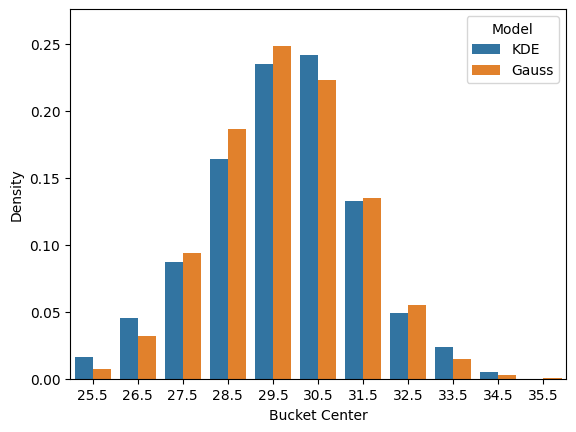

In [1]:
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
sys.path.append("/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project")

from data.fetcher import fetch_data
from data.cleaner import clean_data
from data.loader import add_event_column,filter_summer,get_separate_summer_months
from config.settings import HISTORICAL_START,HISTORICAL_END,DEFAULT_CITY
from scipy.stats import norm
from models.baseline import gaussian_probability
from models.kde_model import kde_estimate


df_raw = fetch_data(HISTORICAL_START,HISTORICAL_END)


df_clean = clean_data(df_raw)


df_event = add_event_column(df_clean)


df_temp_summer = filter_summer(df_event)

df_temp_list = df_temp_summer["temperature_2m_max"].to_list()

df_sorted = sorted(df_temp_list)

sns.kdeplot(data = df_sorted)


lower_b = -1000
upper_b = 29.5
P = kde_estimate(df_sorted,lower_b,upper_b)

print(f"Probability is {P}, when lower_bound is {lower_b} and upper_b is {upper_b}")

count = 0
data = []
for i in range (25,36):
    bucket_center = i + 0.5
    P_kde = kde_estimate(df_sorted,i,i+1)
    P_gauss,a,b = gaussian_probability(df_sorted,i,i+1)
    if P_kde > P_gauss:
        count+= 1
        print(f"Större än på bucket {i} och detta är den {count}:gången")
    data.append((bucket_center, "KDE", P_kde))
    data.append((bucket_center, "Gauss", P_gauss))
    
long_df = pl.DataFrame(data,schema = ['Bucket Center', 'Model', 'Probability'],orient = "row" )


sns.barplot(data=long_df, x="Bucket Center", y="Probability", hue="Model")

We notice here that 5 buckets have the KDE assigning a higher probability than the Gaussian. The buckets where KDE had a higher probability density were 25, 26, 30, 33 and 34. This is effectively from the different months that play in. We could see from notebook 02 that the three months are not symmetric and some have spikes. This is really seen here. It leaves traces that some buckets are much more common.

If you consider how these models are defined, Gauss takes two parameters and forces a smooth, symmetric bell curve shape, whereas KDE actually follows the data points directly. We can't be certain though which model performs best — we need to evaluate and calibrate.

We see that Gauss wins around the center and KDE wins at the shoulders, with one exception near the center at 30.